# Dual Fast Extragradient Method for Monotone Lipschitz Operators

We consider a monotone and $L$-Lipschitz continuous operator $A$ with a zero $x_\star$,
$$
    A(x_\star)=0, \qquad \|x_0-x_\star\|^2 \le R^2.
$$
The step size is $\alpha=1/L$. The dual FEG recursion is initialized with $z_0=0$ and, for $k=0,\ldots,N-1$, uses
$$
    x_{k+1/2}=x_k-\alpha z_k-\alpha A(x_k),
$$
$$
    x_{k+1}=x_{k+1/2}-\frac{N-k-1}{N-k}\alpha\left(A(x_{k+1/2})-A(x_k)\right),
$$
$$
    z_{k+1}=\frac{N-k-1}{N-k}z_k-\frac{1}{N-k}A(x_{k+1/2}).
$$
The Block 1 performance metric is the final residual $\|A(x_N)\|^2$. The last update has $z_N=-A(x_N)$, so this also measures the final dual residual.

Numerical PEP evidence suggests
$$
    \|A(x_N)\|^2 \le \frac{4L^2R^2}{N^2}\quad (N\ge 2),
$$
with a tighter value $2L^2R^2$ at $N=1$.

## Proof Statement

### Theorem

Assume $A$ is monotone and $L$-Lipschitz, $A(x_{\star})=0$, and $\|x_{0}-x_{\star}\|^2\le R^2$. Let $N\ge 2$, set $\alpha=1/L$, initialize $z_{0}=0$, and generate

$$
x_{k+1/2}=x_k-\alpha z_k-\alpha A(x_k),
$$

$$
x_{k+1}=x_{k+1/2}-\frac{N-k-1}{N-k}\alpha\left(A(x_{k+1/2})-A(x_k)\right),
$$

$$
z_{k+1}=\frac{N-k-1}{N-k}z_k-\frac{1}{N-k}A(x_{k+1/2})
$$

for $k=0,\ldots,N-1$. For $1\le k\le N-1$, define

$$
V_k=-2\|A(x_N)\|^2+2\|z_k+A(x_N)\|^2
+\frac{4L}{N}\langle A(x_N),x_0-x_N\rangle
-\frac{4L}{N-k}\langle z_k+A(x_N),x_k-x_N\rangle.
$$

The terminal value is defined by

$$
V_N=V_{N-1}-2I^{\rm lip}(x_{N-1},x_N),
$$

where

$$
I^{\rm lip}(u,v)=\|A(u)-A(v)\|^2-L^2\|u-v\|^2\le 0.
$$

Then

$$
\|A(x_N)\|^2\le \frac{4L^2R^2}{N^2}.
$$

### Proof outline

Use the residual conventions

$$
I^{\rm mon}(u,v)=-\langle u-v,A(u)-A(v)\rangle\le 0,
$$

$$
I^{\rm lip}(u,v)=\|A(u)-A(v)\|^2-L^2\|u-v\|^2\le 0.
$$

The base identity is

$$
V_1+\frac{2}{N^2}I^{\rm lip}(x_0,x_{1/2})
+\frac{4}{N(N-1)}I^{\rm mon}(x_{1/2},x_N)=0.
$$

For $1\le k\le N-2$, the one-step identity is

$$
V_{k+1}-V_k
+\frac{2}{(N-k)^2}I^{\rm lip}(x_k,x_{k+1/2})
+\frac{4}{(N-k-1)(N-k)}I^{\rm mon}(x_{k+1/2},x_N)=0.
$$

The final partial-sum increment is

$$
V_N-V_{N-1}+2I^{\rm lip}(x_{N-1},x_N)=0.
$$

Finally define

$$
S=\left\|A(x_N)-\frac{2L}{N}(x_0-x_{\star})\right\|^2\ge 0.
$$

The boundary identity is

$$
\|A(x_N)\|^2-\frac{4L^2}{N^2}\|x_0-x_{\star}\|^2
+V_N-\frac{4}{N}I^{\rm mon}(x_N,x_{\star})+S=0.
$$

All coefficients multiplying interpolation residuals are nonnegative, all residuals are nonpositive, and $S\ge 0$. The boundary identity therefore implies the claimed residual bound.

## Imports

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pepflow").exists():
    REPO_ROOT = REPO_ROOT.parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import sympy as sp  # noqa: E402
import pepflow as pf  # noqa: E402
from pepflow.lyapunov_utils import (  # noqa: E402
    find_symmetric_coefficient_matrix,
    vectors_in_column_space,
)

STATE_DIR = REPO_ROOT / "examples_peppy" / "dual-feg" / "state"

## Operator and Parameters

In [2]:
L = pf.Parameter("L")
R = pf.Parameter("R")
A = pf.LipschitzMonotoneOperator(is_basis=True, tags=["A"], L=L)

## PEP Setup

In [3]:
def make_ctx_dual_feg(ctx_name: str, N, **kwargs) -> pf.PEPContext:
    """Build the PEPContext encoding N steps of dual FEG."""
    N_int = int(N)
    ctx = pf.PEPContext(ctx_name).set_as_current()

    x = pf.Vector(is_basis=True, tags=["x_0"])
    z = pf.Vector.zero().add_tag("z_0")
    A.set_zero_point("x_star")

    for k in range(N_int):
        theta = sp.Rational(N_int - k - 1, N_int - k)
        inv_remaining = sp.Rational(1, N_int - k)

        x_half = x - (sp.S(1) / L) * z - (sp.S(1) / L) * A(x)
        x_half.add_tag(f"x_{k + 0.5}")

        x_next = x_half - theta * (sp.S(1) / L) * (A(x_half) - A(x))
        x_next.add_tag(f"x_{k + 1}")

        z_next = theta * z - inv_remaining * A(x_half)
        z_next.add_tag(f"z_{k + 1}")

        x = x_next
        z = z_next

    return ctx


def get_pep_setup(N, params):
    """Standard interface for pep_runner.py."""
    ctx = make_ctx_dual_feg(f"ctx_{N}", N)
    pb = pf.PEPBuilder(ctx)
    pb.add_initial_constraint(
        ((ctx["x_0"] - ctx["x_star"]) ** 2).le(R**2, name="initial_condition")
    )
    pb.set_performance_metric(A(ctx[f"x_{N}"]) ** 2)
    return ctx, pb, A

## Numerical Evidence

N=1: PEP=1.99999864, candidate=2.00000000
N=2: PEP=1.00005152, candidate=1.00000000
N=3: PEP=0.44447345, candidate=0.44444444
N=4: PEP=0.25000040, candidate=0.25000000
N=5: PEP=0.16000072, candidate=0.16000000
N=6: PEP=0.11111809, candidate=0.11111111
N=7: PEP=0.08163549, candidate=0.08163265


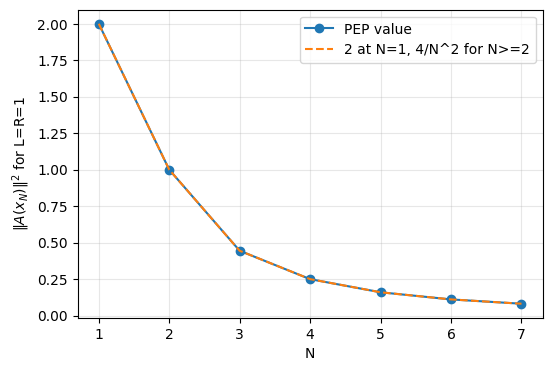

In [4]:
import json

with (STATE_DIR / "dual_feg_b1.json").open() as fh:
    state = json.load(fh)

Ns = np.array([row["N"] for row in state["sweep_results"]], dtype=float)
pep_values = np.array([float(row["opt_value"]) for row in state["sweep_results"]])
rate_guess = 4 / Ns**2
rate_guess[0] = 2.0

for N, value, guess in zip(Ns.astype(int), pep_values, rate_guess):
    print(f"N={N}: PEP={value:.8f}, candidate={guess:.8f}")

plt.figure(figsize=(6, 4))
plt.plot(Ns, pep_values, "o-", label="PEP value")
plt.plot(Ns, rate_guess, "--", label="2 at N=1, 4/N^2 for N>=2")
plt.xlabel("N")
plt.ylabel(r"$\|A(x_N)\|^2$ for L=R=1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Candidate Rate

The Block 1 sweep supports the candidate residual bound $4L^2R^2/N^2$ for $N\ge 2$, with a separate tight value $2L^2R^2$ at $N=1$. Later blocks should derive and verify the dual certificate, the Lyapunov construction, and the symbolic step/base/boundary identities.

## Full-PEP Proof Certificate

Block 2 solves the dense PEP at `N_verify=4`, enforces the closed-form sparse active set, and verifies the exact fixed-horizon proof identity.

In [5]:
import json

with (STATE_DIR / "dual_feg_b2.json").open() as fh:
    b2 = json.load(fh)
with (STATE_DIR / "dual_feg_dense.json").open() as fh:
    dense = json.load(fh)
with (STATE_DIR / "dual_feg_relaxed.json").open() as fh:
    relaxed = json.load(fh)

print("dense opt:", f"{float(dense['opt_value']):.10f}")
print("relaxed opt:", f"{float(relaxed['opt_value']):.10f}")
print("target rate:", 4 / b2["N_verify"] ** 2)
print("relaxed constraints dropped:", len(b2["relaxed_constraints"]))
print("basis vectors:", b2["basis_vectors"])

dense opt: 0.2500004040
relaxed opt: 0.2500011996
target rate: 0.25
relaxed constraints dropped: 154
basis vectors: ['x_0', 'x_star', 'A(x_0)', 'A(x_0.5)', 'A(x_1)', 'A(x_1.5)', 'A(x_2)', 'A(x_2.5)', 'A(x_3)', 'A(x_3.5)', 'A(x_4)']


### Active Sparse Constraints

The sparse proof keeps only monotonicity constraints from the intermediate half-steps to the final point, the final monotonicity constraint against the zero, the half-step Lipschitz constraints, and the last full-step Lipschitz constraint.

In [6]:
N_int = b2["N_verify"]
active_constraints = []
for h in range(N_int - 1):
    active_constraints.append(f"A monotone:x_{h}.5,x_{N_int}")
active_constraints.append(f"A monotone:x_{N_int},x_star")
for i in range(N_int - 1):
    active_constraints.append(f"A Lipschitz:x_{i},x_{i}.5")
active_constraints.append(f"A Lipschitz:x_{N_int - 1},x_{N_int}")
for name in active_constraints:
    print(name)

A monotone:x_0.5,x_4
A monotone:x_1.5,x_4
A monotone:x_2.5,x_4
A monotone:x_4,x_star
A Lipschitz:x_0,x_0.5
A Lipschitz:x_1,x_1.5
A Lipschitz:x_2,x_2.5
A Lipschitz:x_3,x_4


### Closed-Form Lambda

In [7]:
def lamb_mono(ri, ci, N=N_int):
    for h in range(N - 1):
        if ri == f"x_{h}.5" and ci == f"x_{N}":
            return sp.Rational(4, (N - h - 1) * (N - h))
    if ri == f"x_{N}" and ci == "x_star":
        return sp.Rational(4, N)
    return sp.S(0)


def lamb_lip(ri, ci, N=N_int):
    for i in range(N - 1):
        if ri == f"x_{i}" and ci == f"x_{i}.5":
            return sp.Rational(2, (N - i) ** 2)
    if ri == f"x_{N - 1}" and ci == f"x_{N}":
        return sp.S(2)
    return sp.S(0)


def lamb(group, ri, ci, N=N_int):
    if group == "Monotone Operator Inequality":
        return lamb_mono(ri, ci, N)
    if group == "Lipschitz Continuous Inequality":
        return lamb_lip(ri, ci, N)
    return sp.S(0)


mono_group = relaxed["lambda_groups"]["Monotone Operator Inequality"]
lip_group = relaxed["lambda_groups"]["Lipschitz Continuous Inequality"]
mono_rows, mono_cols = mono_group["row_names"], mono_group["col_names"]
lip_rows, lip_cols = lip_group["row_names"], lip_group["col_names"]

mono_cand = pf.pprint_labeled_matrix(
    lamb_mono, mono_rows, mono_cols, precision=6, return_matrix=True
)
lip_cand = pf.pprint_labeled_matrix(
    lamb_lip, lip_rows, lip_cols, precision=6, return_matrix=True
)
mono_cand_arr = np.asarray(mono_cand, dtype=float)
print("monotone candidate nonzeros:", int(np.sum(np.abs(mono_cand_arr) > 1e-12)))
lip_cand_arr = np.asarray(lip_cand, dtype=float)
print("Lipschitz candidate nonzeros:", int(np.sum(np.abs(lip_cand_arr) > 1e-12)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

monotone candidate nonzeros: 4
Lipschitz candidate nonzeros: 4


### Rank-One S Certificate

In [8]:
ctx_prf, pb_prf, obj = get_pep_setup(N_int, {"L": 1, "R": 1})
pm = pf.ExpressionManager(ctx_prf, resolve_parameters={"L": 1, "R": 1})
x_N = ctx_prf[f"x_{N_int}"]
x_0 = ctx_prf["x_0"]
x_star = ctx_prf["x_star"]

S_guess = (obj(x_N) - sp.Rational(2, N_int) * (x_0 - x_star)) ** 2
S_guess_matrix = pm.eval_scalar(S_guess).inner_prod_coords.astype(float)
pf.pprint_labeled_matrix(
    S_guess_matrix, b2["S_row_names"], b2["S_col_names"], precision=6
)
print("S rank:", np.linalg.matrix_rank(S_guess_matrix, tol=1e-9))

<IPython.core.display.Math object>

S rank: 1


### Full Proof Identity

The verified identity is

$$
\|A(x_N)\|^2 - \frac{4}{N^2}\|x_0-x_\star\|^2 - \sum_i \lambda_i I_i + S = 0,
$$

where each interpolation residual satisfies $I_i\le 0$ and $S\succeq 0$.

In [9]:
ineq_sum = pf.Scalar.zero()
for h in range(N_int - 1):
    ineq_sum += lamb_mono(f"x_{h}.5", f"x_{N_int}") * obj.monotone_ineq(
        f"x_{h}.5", f"x_{N_int}", ctx_prf
    )
ineq_sum += lamb_mono(f"x_{N_int}", "x_star") * obj.monotone_ineq(
    f"x_{N_int}", "x_star", ctx_prf
)
for i in range(N_int - 1):
    ineq_sum += lamb_lip(f"x_{i}", f"x_{i}.5") * obj.lipschitz_ineq(
        f"x_{i}", f"x_{i}.5", ctx_prf
    )
ineq_sum += lamb_lip(f"x_{N_int - 1}", f"x_{N_int}") * obj.lipschitz_ineq(
    f"x_{N_int - 1}", f"x_{N_int}", ctx_prf
)

proof_diff = (
    obj(x_N) ** 2 - sp.Rational(4, N_int**2) * (x_0 - x_star) ** 2 - ineq_sum + S_guess
)
proof_matrix = pm.eval_scalar(proof_diff).inner_prod_coords.astype(float)
pf.pprint_labeled_matrix(
    proof_matrix, b2["S_row_names"], b2["S_col_names"], precision=6
)
print("Proof valid:", np.allclose(proof_matrix, 0, atol=1e-10))
print("Proof residual max abs:", np.max(np.abs(proof_matrix)))

<IPython.core.display.Math object>

Proof valid: True
Proof residual max abs: 6.938893903907228e-17


## Dense and Relaxed Proof Solves

Completed in Block 2.

## Closed-Form Lambda and S Verification

Completed in Block 2.

## Partial-Sum Lyapunov Construction and Rank Profile

Using the Block 2 identity
$$
\|A(x_N)\|^2-\frac{4}{N^2}\|x_0-x_\star\|^2-
\sum_i \lambda_i I_i+S=0,
$$
we define partial sums by accumulating the negative weighted interpolation residuals. For $0\le k\le N-2$,
$$
V_{k+1}-V_k
= -\frac{2}{(N-k)^2}I^{\rm lip}(x_k,x_{k+1/2})
  -\frac{4}{(N-k-1)(N-k)}I^{\rm mon}(x_{k+1/2},x_N),
$$
and the final increment is
$$
V_N-V_{N-1}=-2I^{\rm lip}(x_{N-1},x_N).
$$
The rank-one term $S=\|A(x_N)-\frac{2}{N}(x_0-x_\star)\|^2$ remains as a boundary certificate rather than being split across the partial sums.

In [10]:
with (STATE_DIR / "dual_feg_b3.json").open() as fh:
    b3 = json.load(fh)

N_int = b3["N_verify"]
ctx_lyap, pb_lyap, obj = get_pep_setup(N_int, {"L": 1, "R": 1})
pm = pf.ExpressionManager(ctx_lyap, resolve_parameters={"L": 1, "R": 1})
ctx = ctx_lyap
rank_tolerance = b3["rank_tolerance"]

print("extra duals:", b3["extra_duals"])
print("S ingredient:", b3["S_piece_code"])

extra duals: {}
S ingredient: S is kept as the rank-one boundary term from Block 2; no per-step S pieces are subtracted in V_k.


C:\Users\Jack\Documents\GitHub\PEPFlow_public\pepflow\pep_context.py:172: UserWarning:

The provided name was already used. The older PEPContext will be overwritten. PEPBuilders constructed with the older PEPContext should be remade.



In [11]:
def mono_weight(h, N=N_int):
    return sp.Rational(4, (N - h - 1) * (N - h))


def lip_weight(i, N=N_int):
    return sp.Rational(2, (N - i) ** 2)


lyap = [pf.Scalar.zero()]
partial_sum = pf.Scalar.zero()
for step in range(N_int):
    if step < N_int - 1:
        partial_sum = partial_sum - lip_weight(step) * obj.lipschitz_ineq(
            f"x_{step}", f"x_{step}.5", ctx
        )
        partial_sum = partial_sum - mono_weight(step) * obj.monotone_ineq(
            f"x_{step}.5", f"x_{N_int}", ctx
        )
    else:
        partial_sum = partial_sum - 2 * obj.lipschitz_ineq(
            f"x_{N_int - 1}", f"x_{N_int}", ctx
        )
    lyap.append(partial_sum)

ranks = []
for k, Vk in enumerate(lyap):
    matrix = pm.eval_scalar(Vk).inner_prod_coords.astype(float)
    rank = int(np.linalg.matrix_rank(matrix, tol=rank_tolerance))
    ranks.append(rank)
    print(f"rank V_{k}: {rank}")
    if k == 0:
        print()

print("Interior rank is constant:", len(set(ranks[1:N_int])) == 1)

rank V_0: 0



rank V_1: 4
rank V_2: 4
rank V_3: 4
rank V_4: 2
Interior rank is constant: True


In [12]:
M_final = pm.eval_scalar(lyap[N_int]).inner_prod_coords.astype(float)
rank_final = int(np.linalg.matrix_rank(M_final, tol=rank_tolerance))
print(f"lyap[{N_int}] rank:", rank_final)
print("Stored rank profile matches:", ranks == b3["rank_profile"])
print("Boundary note:", b3["coverage_note"])

lyap[4] rank: 2
Stored rank profile matches: True
Boundary note: V_N has rank 2, as in the FEG residual proof family; the remaining boundary identity combines V_N with the rank-one S term and the performance-rate expression.


## Identify the vectors composing the Lyapunov function

Block 4 starts from the Block 3 partial sums and searches for interpretable rank-spanning vectors. The interior rank is 4, and the selected template combines the terminal residual, the dual state, the initial-to-terminal gap, and the current-to-terminal gap.

### Candidate-vector scan

The scan uses tagged iterates and half-steps, operator values, point-to-solution gaps, point-to-terminal gaps, operator-output differences, and the auxiliary dual states `z_k`. Duplicate and zero candidates are removed by evaluated coordinates.

In [13]:
candidate_labels = {}
candidates = []


def _coords(v):
    return np.array(pm.eval_vector(v).coords, dtype=float)


def add_candidate(label, v):
    coords = _coords(v)
    if np.linalg.norm(coords) < 1e-10:
        return
    key = tuple(np.round(coords, 10))
    if key in candidate_labels:
        return
    candidate_labels[key] = label
    candidates.append((label, v))


def candidate_label(v):
    key = tuple(np.round(_coords(v), 10))
    return candidate_labels.get(key, str(v))


point_tags = (
    [f"x_{i}" for i in range(N_int + 1)]
    + [f"x_{i}.5" for i in range(N_int)]
    + ["x_star"]
)
for tag in point_tags:
    add_candidate(tag, ctx[tag])
    add_candidate(f"A({tag})", obj(ctx[tag]))
    add_candidate(f"{tag}-x_star", ctx[tag] - ctx["x_star"])
for i in range(N_int + 1):
    add_candidate(f"z_{i}", ctx[f"z_{i}"])
    add_candidate(f"z_{i}+A(x_{N_int})", ctx[f"z_{i}"] + obj(ctx[f"x_{N_int}"]))
for i in range(N_int + 1):
    add_candidate(f"x_0-x_{i}", ctx["x_0"] - ctx[f"x_{i}"])
    add_candidate(f"x_{i}-x_{N_int}", ctx[f"x_{i}"] - ctx[f"x_{N_int}"])

print("candidate count:", len(candidates))

candidate count: 41


In [14]:
for k in range(1, N_int):
    in_col = vectors_in_column_space(
        lyap[k],
        [v for _, v in candidates],
        pep_context=ctx,
        resolve_parameters={"L": 1, "R": 1},
        rtol=1e-4,
        atol=1e-4,
    )
    print(f"V_{k} column-space candidates:")
    for v in in_col:
        print("  ", candidate_label(v))

V_1 column-space candidates:
   A(x_0)
   A(x_4)
   A(x_0.5)
   z_1
   z_1+A(x_4)
   x_0-x_4
   x_0-x_1
   x_1-x_4
V_2 column-space candidates:
   A(x_4)
   z_2
   z_2+A(x_4)
   x_0-x_4
   x_0-x_2
   x_2-x_4


V_3 column-space candidates:


   A(x_3)
   A(x_4)
   z_3
   z_3+A(x_4)
   x_0-x_4
   x_0-x_3
   x_3-x_4


### Selected basis pattern

For each interior $1\le k\le N-1$, we use the ordered basis
$$
\left[A(x_N),\ z_k+A(x_N),\ x_0-x_N,\ x_k-x_N\right].
$$

In [15]:
def V_k_basis(k):
    return [
        obj(ctx[f"x_{N_int}"]),
        ctx[f"z_{k}"] + obj(ctx[f"x_{N_int}"]),
        ctx["x_0"] - ctx[f"x_{N_int}"],
        ctx[f"x_{k}"] - ctx[f"x_{N_int}"],
    ]


def V_k_basis_labels(k):
    return [
        f"A(x_{N_int})",
        f"z_{k}+A(x_{N_int})",
        f"x_0-x_{N_int}",
        f"x_{k}-x_{N_int}",
    ]


for k in range(1, N_int):
    basis_matrix = np.stack([_coords(v) for v in V_k_basis(k)], axis=1)
    print(
        f"k={k}: rank {np.linalg.matrix_rank(basis_matrix, tol=1e-7)} basis {V_k_basis_labels(k)}"
    )

k=1: rank 4 basis ['A(x_4)', 'z_1+A(x_4)', 'x_0-x_4', 'x_1-x_4']
k=2: rank 4 basis ['A(x_4)', 'z_2+A(x_4)', 'x_0-x_4', 'x_2-x_4']
k=3: rank 4 basis ['A(x_4)', 'z_3+A(x_4)', 'x_0-x_4', 'x_3-x_4']


### Coefficient matrices

The coefficient matrix is displayed in the selected basis order above.

In [16]:
def coeff_pattern(k, N):
    return sp.Matrix(
        [
            [-sp.S(2), sp.S(0), sp.Rational(2, N), sp.S(0)],
            [sp.S(0), sp.S(2), sp.S(0), -sp.Rational(2, N - k)],
            [sp.Rational(2, N), sp.S(0), sp.S(0), sp.S(0)],
            [sp.S(0), -sp.Rational(2, N - k), sp.S(0), sp.S(0)],
        ]
    )


coeff_by_k = {}
for k in range(1, N_int):
    basis = V_k_basis(k)
    labels_k = V_k_basis_labels(k)
    C = find_symmetric_coefficient_matrix(
        lyap[k], basis, pep_context=ctx, resolve_parameters={"L": 1, "R": 1}
    )
    coeff_by_k[k] = C
    C_formula = np.array(coeff_pattern(k, N_int), dtype=float)
    print(f"k={k}: formula residual {np.max(np.abs(C - C_formula)):.2e}")
    pf.pprint_labeled_matrix(C, labels_k, labels_k, precision=6)

print(
    "coefficient formula verified:",
    all(
        np.max(np.abs(C - np.array(coeff_pattern(k, N_int), dtype=float))) < 1e-8
        for k, C in coeff_by_k.items()
    ),
)

k=1: formula residual 4.00e-15

<IPython.core.display.Math object>

k=2: formula residual 3.33e-15


<IPython.core.display.Math object>

k=3: formula residual 1.11e-15


<IPython.core.display.Math object>

coefficient formula verified: True


### Block 4 conclusion

The interior Lyapunov partial sums are represented by
$$
V_k = v_k^\top C_k v_k,
\quad
v_k=\left(A(x_N),\ z_k+A(x_N),\ x_0-x_N,\ x_k-x_N\right),
$$
with
$$
C_k=\begin{bmatrix}
-2&0&2/N&0\\
0&2&0&-2/(N-k)\\
2/N&0&0&0\\
0&-2/(N-k)&0&0
\end{bmatrix}.
$$
Block 5 will verify the closed-form step, base, and boundary identities symbolically.

## Coefficient Extraction and Closed-Form V_k

Completed in Block 4; Block 5 will perform symbolic verification.

## Symbolic Step Recursion Verification

The identity verified below is

$$
V_{k+1}-V_k
+\frac{2}{(N-k)^2}I^{\rm lip}(x_k,x_{k+1/2})
+\frac{4}{(N-k-1)(N-k)}I^{\rm mon}(x_{k+1/2},x_N)=0.
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [17]:
b5 = json.load((STATE_DIR / "dual_feg_b5.json").open())

k_param = pf.Parameter("k")
N_param = pf.Parameter("N")
k_symbol = sp.Symbol("k", positive=True, integer=True)
N_symbol = sp.Symbol("N", positive=True, integer=True)

ctx_step = pf.PEPContext("dual_feg_symbolic_step").set_as_current()
A_step = pf.LipschitzMonotoneOperator(is_basis=True, tags=["A_{step}"], L=1)
x_N_step = pf.Vector(is_basis=True, tags=["x_N"])
d_k_step = pf.Vector(is_basis=True, tags=["d_k"])
p_step = pf.Vector(is_basis=True, tags=["p"])
b_k_step = pf.Vector(is_basis=True, tags=["b_k"])
x_k_step = (x_N_step + d_k_step).add_tag("x_k")
x_0_step = (x_N_step + p_step).add_tag("x_0")
z_k_step = b_k_step - A_step(x_N_step)
theta_step = (N_param - k_param - 1) / (N_param - k_param)
x_half_step = (x_k_step - z_k_step - A_step(x_k_step)).add_tag("x_h")
x_k1_step = (
    x_half_step - (A_step(x_half_step) - A_step(x_k_step)) * theta_step
).add_tag("x_k1")
z_k1_step = z_k_step * theta_step - A_step(x_half_step) / (N_param - k_param)
b_k1_step = z_k1_step + A_step(x_N_step)


def V_symbolic_step(d_vec, b_vec, kk):
    a_vec = A_step(x_N_step)
    p_vec = x_0_step - x_N_step
    return (
        -2 * a_vec**2
        + 2 * b_vec**2
        + (4 / N_param) * (a_vec * p_vec)
        - (4 / (N_param - kk)) * (b_vec * d_vec)
    )


V_k_step = V_symbolic_step(x_k_step - x_N_step, b_k_step, k_param)
V_k1_step = V_symbolic_step(x_k1_step - x_N_step, b_k1_step, k_param + 1)
LHS_step = V_k1_step - V_k_step
RHS_step = -(
    (2 / (N_param - k_param) ** 2) * A_step.lipschitz_ineq("x_k", "x_h", ctx_step)
    + (4 / ((N_param - k_param - 1) * (N_param - k_param)))
    * A_step.monotone_ineq("x_h", "x_N", ctx_step)
)
diff_step = LHS_step - RHS_step
pm_step = pf.ExpressionManager(
    ctx_step, resolve_parameters={"k": k_symbol, "N": N_symbol}
)
step_residual = sp.Matrix(pm_step.eval_scalar(diff_step).inner_prod_coords).applyfunc(
    sp.simplify
)
pf.pprint_labeled_matrix(
    np.array(step_residual.tolist(), dtype=object),
    [str(v) for v in ctx_step.basis_vectors()],
    [str(v) for v in ctx_step.basis_vectors()],
)
print("Step identity zero:", step_residual == sp.zeros(*step_residual.shape))

<IPython.core.display.Math object>

Step identity zero: True


## Base Case Symbolic Verification

The identity verified below is

$$
V_1+\frac{2}{N^2}I^{\rm lip}(x_0,x_{1/2})
+\frac{4}{N(N-1)}I^{\rm mon}(x_{1/2},x_N)=0.
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [18]:
ctx_base = pf.PEPContext("dual_feg_symbolic_base").set_as_current()
A_base = pf.LipschitzMonotoneOperator(is_basis=True, tags=["A_{base}"], L=1)
N_base = pf.Parameter("N")
x_N_base = pf.Vector(is_basis=True, tags=["x_N"])
p_base = pf.Vector(is_basis=True, tags=["p"])
x_0_base = (x_N_base + p_base).add_tag("x_0")
z_0_base = pf.Vector.zero()
x_half_base = (x_0_base - A_base(x_0_base)).add_tag("x_0.5")
theta_base = (N_base - 1) / N_base
x_1_base = (
    x_half_base - (A_base(x_half_base) - A_base(x_0_base)) * theta_base
).add_tag("x_1")
z_1_base = -A_base(x_half_base) / N_base
b_1_base = z_1_base + A_base(x_N_base)

a_base = A_base(x_N_base)
V_1_base = (
    -2 * a_base**2
    + 2 * b_1_base**2
    + (4 / N_base) * (a_base * (x_0_base - x_N_base))
    - (4 / (N_base - 1)) * (b_1_base * (x_1_base - x_N_base))
)
LHS_base = V_1_base
RHS_base = -(
    (2 / N_base**2) * A_base.lipschitz_ineq("x_0", "x_0.5", ctx_base)
    + (4 / ((N_base - 1) * N_base)) * A_base.monotone_ineq("x_0.5", "x_N", ctx_base)
)
diff_base = LHS_base - RHS_base
pm_base = pf.ExpressionManager(ctx_base, resolve_parameters={"N": N_symbol})
base_residual = sp.Matrix(pm_base.eval_scalar(diff_base).inner_prod_coords).applyfunc(
    sp.simplify
)
pf.pprint_labeled_matrix(
    np.array(base_residual.tolist(), dtype=object),
    [str(v) for v in ctx_base.basis_vectors()],
    [str(v) for v in ctx_base.basis_vectors()],
)
print("Base identity zero:", base_residual == sp.zeros(*base_residual.shape))

<IPython.core.display.Math object>

Base identity zero: True


### Boundary Identity Symbolic Verification

The identity verified below is

$$
\|A(x_N)\|^2-\frac{4}{N^2}\|x_0-x_\star\|^2
+V_N-\frac{4}{N}I^{\rm mon}(x_N,x_\star)+S=0.
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [19]:
ctx_boundary = pf.PEPContext("dual_feg_symbolic_boundary").set_as_current()
A_boundary = pf.LipschitzMonotoneOperator(is_basis=True, tags=["A_{boundary}"], L=1)
N_boundary = pf.Parameter("N")
x_prev_boundary = pf.Vector(is_basis=True, tags=["x_{N-1}"])
d_boundary = pf.Vector(is_basis=True, tags=["d"])
p_boundary = pf.Vector(is_basis=True, tags=["p"])
x_star_boundary = A_boundary.set_zero_point("x_star")
x_N_boundary = (x_prev_boundary - d_boundary).add_tag("x_N")
x_0_boundary = (x_N_boundary + p_boundary).add_tag("x_0")

# The final Dual FEG half-step has x_N=x_{N-1}-z_{N-1}-A(x_{N-1}),
# so z_{N-1}+A(x_N)=d-A(x_{N-1})+A(x_N).
b_prev_boundary = d_boundary - A_boundary(x_prev_boundary) + A_boundary(x_N_boundary)
V_prev_boundary = (
    -2 * A_boundary(x_N_boundary) ** 2
    + 2 * b_prev_boundary**2
    + (4 / N_boundary) * (A_boundary(x_N_boundary) * (x_0_boundary - x_N_boundary))
    - 4 * (b_prev_boundary * (x_prev_boundary - x_N_boundary))
)
V_N_boundary = V_prev_boundary - 2 * A_boundary.lipschitz_ineq(
    "x_{N-1}", "x_N", ctx_boundary
)
S_boundary = (
    A_boundary(x_N_boundary) - (2 / N_boundary) * (x_0_boundary - x_star_boundary)
) ** 2
LHS_boundary = (
    A_boundary(x_N_boundary) ** 2
    - (4 / N_boundary**2) * (x_0_boundary - x_star_boundary) ** 2
    + V_N_boundary
    - (4 / N_boundary) * A_boundary.monotone_ineq("x_N", "x_star", ctx_boundary)
    + S_boundary
)
RHS_boundary = pf.Scalar.zero()
diff_boundary = LHS_boundary - RHS_boundary
pm_boundary = pf.ExpressionManager(ctx_boundary, resolve_parameters={"N": N_symbol})
boundary_residual = sp.Matrix(
    pm_boundary.eval_scalar(diff_boundary).inner_prod_coords
).applyfunc(sp.simplify)
pf.pprint_labeled_matrix(
    np.array(boundary_residual.tolist(), dtype=object),
    [str(v) for v in ctx_boundary.basis_vectors()],
    [str(v) for v in ctx_boundary.basis_vectors()],
)
print(
    "Boundary identity zero:", boundary_residual == sp.zeros(*boundary_residual.shape)
)

<IPython.core.display.Math object>

Boundary identity zero: True


## Final Theorem

For every $N\ge 2$, the Dual FEG iterates satisfy

$$
\|A(x_N)\|^2\le \frac{4L^2}{N^2}\|x_0-x_\star\|^2.
$$

The proof follows by summing the base, step, and final increment identities, then applying the boundary identity with $S\ge 0$ and $I^{\rm mon},I^{\rm lip}\le 0$.